# 3-Class Baselines + Sentence-BERT

This single notebook creates fair 3-class comparison baselines for the POLITICS

It runs two groups of models:

1. Classical full-article baselines: majority class, TF-IDF + logistic regression, TF-IDF + linear SVM, bag-of-words + Naive Bayes.
2. Sentence-BERT embedding baselines: full-article chunk embeddings averaged into article vectors, then logistic regression and linear SVM.

All models use the same left/center/right label mapping.

## 1. Install and Import Libraries

In [1]:
!pip -q install sentence-transformers scikit-learn pandas numpy matplotlib seaborn joblib

In [2]:
import os
import re
import shutil
import warnings

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from google.colab import files
from sentence_transformers import SentenceTransformer
from sklearn.dummy import DummyClassifier
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, f1_score
from sklearn.naive_bayes import MultinomialNB
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import LinearSVC

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid")

## 2. Configuration

In [3]:
SEED = 42
np.random.seed(SEED)

DATA_DIR = "/content/chethas_preprocessing_outputs"
OUTPUT_DIR = "/content/three_class_all_baselines_outputs"
os.makedirs(DATA_DIR, exist_ok=True)
os.makedirs(OUTPUT_DIR, exist_ok=True)

TRAIN_CSV = os.path.join(DATA_DIR, "train_processed.csv")
VAL_CSV = os.path.join(DATA_DIR, "val_processed.csv")

LABEL_NAMES = ["left", "center", "right"]
ID_TO_LABEL = dict(enumerate(LABEL_NAMES))
LABEL_TO_ID = {name: i for i, name in ID_TO_LABEL.items()}

# Original 5-class labels:
# 0=right, 1=right-center, 2=least-biased, 3=left-center, 4=left
THREE_CLASS_MAP = {
    0: 2,
    1: 2,
    2: 1,
    3: 0,
    4: 0,
}

# Main input column for classical baselines and Sentence-BERT.
TEXT_COL = "clean_text"

# Sentence-BERT settings. Stronger/slower: all-mpnet-base-v2. Faster: all-MiniLM-L6-v2.
SBERT_MODEL_NAME = "all-mpnet-base-v2"
ENCODE_BATCH_SIZE = 64
MAX_CHUNKS_PER_ARTICLE = None

## 3. Load Processed CSVs From Session

If the files are missing, upload `train_processed.csv` and `val_processed.csv` when prompted.

In [5]:
if not (os.path.exists(TRAIN_CSV) and os.path.exists(VAL_CSV)):
    print("CSV files not found in", DATA_DIR)
    print("Upload train_processed.csv and val_processed.csv now.")
    uploaded = files.upload()
    for filename in uploaded:
        target = os.path.join(DATA_DIR, filename)
        shutil.move(filename, target)
        print("Saved", target)
else:
    print("Found processed CSVs in", DATA_DIR)

Found processed CSVs in /content/chethas_preprocessing_outputs


In [6]:
train_processed = pd.read_csv(TRAIN_CSV)
val_processed = pd.read_csv(VAL_CSV)

print("Train shape:", train_processed.shape)
print("Validation shape:", val_processed.shape)
train_processed.head()

Train shape: (20000, 8)
Validation shape: (4000, 8)


,split,title,raw_text,clean_text,label,label_name,raw_word_count,clean_word_count
0,train,Presumed guilty,"Presumed guilty. <p>Not long ago, my wife Helm...",presumed guilty long ago wife helm one morning...,3,left-center,787,362
1,train,A Judge Just Sentenced the Millionaire Montana...,A Judge Just Sentenced the Millionaire Montana...,judge sentenced millionaire montana politician...,4,left,254,157
2,train,More bodies found in Mexican grave,More bodies found in Mexican grave. <p>..........,body found mexican grave mexico city number ex...,2,least-biased,193,95
3,train,Primary Campaigns Coming to the Finish Line,Primary Campaigns Coming to the Finish Line. <...,primary campaign coming finish line polling pl...,2,least-biased,447,277
4,train,Bush Poaches a Longtime Clinton Backer,Bush Poaches a Longtime Clinton Backer. <p>Lyn...,bush poaches longtime clinton backer lynne sla...,4,left,921,566


## 4. Create 3-Class Labels

In [7]:
required_cols = [TEXT_COL, "label", "label_name"]
missing = [col for col in required_cols if col not in train_processed.columns]
if missing:
    raise ValueError(f"Missing required columns: {missing}")

train_processed = train_processed.reset_index(drop=True).copy()
val_processed = val_processed.reset_index(drop=True).copy()
train_processed["article_id"] = np.arange(len(train_processed))
val_processed["article_id"] = np.arange(len(val_processed))

train_processed["label_3"] = train_processed["label"].map(THREE_CLASS_MAP).astype(int)
val_processed["label_3"] = val_processed["label"].map(THREE_CLASS_MAP).astype(int)
train_processed["label_3_name"] = train_processed["label_3"].map(ID_TO_LABEL)
val_processed["label_3_name"] = val_processed["label_3"].map(ID_TO_LABEL)

print("3-class train labels:")
print(train_processed["label_3_name"].value_counts().reindex(LABEL_NAMES))

print("\n3-class validation labels:")
print(val_processed["label_3_name"].value_counts().reindex(LABEL_NAMES))

3-class train labels:
label_3_name
left      8000
center    4000
right     8000
Name: count, dtype: int64

3-class validation labels:
label_3_name
left      1600
center     800
right     1600
Name: count, dtype: int64


## 5. Classical 3-Class Baselines

In [8]:
X_train_text = train_processed[TEXT_COL].fillna("").astype(str)
X_val_text = val_processed[TEXT_COL].fillna("").astype(str)
y_train = train_processed["label_3"].astype(int)
y_val = val_processed["label_3"].astype(int)

print(X_train_text.shape, X_val_text.shape)
print(y_train.value_counts().sort_index().rename(index=ID_TO_LABEL))

(20000,) (4000,)
label_3
left      8000
center    4000
right     8000
Name: count, dtype: int64


In [9]:
classical_models = {
    "majority_class": DummyClassifier(strategy="most_frequent"),
    "tfidf_logistic_regression": Pipeline([
        ("tfidf", TfidfVectorizer(max_features=80000, ngram_range=(1, 2), min_df=2, max_df=0.9, sublinear_tf=True)),
        ("clf", LogisticRegression(max_iter=2000, class_weight="balanced", n_jobs=-1, random_state=SEED)),
    ]),
    "tfidf_linear_svm": Pipeline([
        ("tfidf", TfidfVectorizer(max_features=80000, ngram_range=(1, 2), min_df=2, max_df=0.9, sublinear_tf=True)),
        ("clf", LinearSVC(class_weight="balanced", random_state=SEED)),
    ]),
    "bow_multinomial_nb": Pipeline([
        ("bow", CountVectorizer(max_features=80000, ngram_range=(1, 2), min_df=2, max_df=0.9)),
        ("clf", MultinomialNB()),
    ]),
}

all_results = []
trained_models = {}
predictions = {}

for name, model in classical_models.items():
    print(f"\nTraining {name}...")
    model.fit(X_train_text, y_train)
    preds = model.predict(X_val_text)

    acc = accuracy_score(y_val, preds)
    macro = f1_score(y_val, preds, average="macro")
    all_results.append({"model": name, "family": "classical", "text_col": TEXT_COL, "accuracy": acc, "macro_f1": macro})
    trained_models[name] = model
    predictions[name] = preds

    print(f"Accuracy: {acc:.4f}")
    print(f"Macro F1: {macro:.4f}")
    print(classification_report(y_val, preds, target_names=LABEL_NAMES, zero_division=0))

classical_results_df = pd.DataFrame(all_results).sort_values("macro_f1", ascending=False)
classical_results_df


Training majority_class...
Accuracy: 0.4000
Macro F1: 0.1905
              precision    recall  f1-score   support

        left       0.40      1.00      0.57      1600
      center       0.00      0.00      0.00       800
       right       0.00      0.00      0.00      1600

    accuracy                           0.40      4000
   macro avg       0.13      0.33      0.19      4000
weighted avg       0.16      0.40      0.23      4000


Training tfidf_logistic_regression...
Accuracy: 0.4225
Macro F1: 0.3281
              precision    recall  f1-score   support

        left       0.41      0.78      0.54      1600
      center       0.29      0.08      0.13       800
       right       0.53      0.23      0.32      1600

    accuracy                           0.42      4000
   macro avg       0.41      0.37      0.33      4000
weighted avg       0.43      0.42      0.37      4000


Training tfidf_linear_svm...
Accuracy: 0.4490
Macro F1: 0.3449
              precision    recall  f1-s

,model,family,text_col,accuracy,macro_f1
2,tfidf_linear_svm,classical,clean_text,0.44900,0.344899
1,tfidf_logistic_regression,classical,clean_text,0.42250,0.328105
3,bow_multinomial_nb,classical,clean_text,0.40525,0.308814
0,majority_class,classical,clean_text,0.40000,0.190476


## 6. Sentence-BERT Chunking

In [10]:
SENTENCE_SPLIT_RE = re.compile(r"(?<=[.!?])\s+|\n+")

def split_into_sentence_chunks(text, max_words=120, min_words=5):
    text = "" if pd.isna(text) else str(text)
    text = re.sub(r"\s+", " ", text).strip()
    if not text:
        return [""]

    pieces = [p.strip() for p in SENTENCE_SPLIT_RE.split(text) if p.strip()]

    # clean_text often has little punctuation, so fall back to word windows.
    if len(pieces) <= 1:
        words = text.split()
        chunks = [" ".join(words[i:i + max_words]) for i in range(0, len(words), max_words)]
        chunks = chunks or [text]
    else:
        chunks = []
        current = []
        current_len = 0

        for piece in pieces:
            words = piece.split()
            if len(words) < min_words and current:
                current.extend(words)
                current_len += len(words)
                continue

            if current and current_len + len(words) > max_words:
                chunks.append(" ".join(current))
                current = words
                current_len = len(words)
            else:
                current.extend(words)
                current_len += len(words)

        if current:
            chunks.append(" ".join(current))

    if MAX_CHUNKS_PER_ARTICLE is not None:
        chunks = chunks[:MAX_CHUNKS_PER_ARTICLE]

    return chunks or [text]

def build_chunk_table(df, text_col=TEXT_COL, split_name="train"):
    rows = []
    for row in df.itertuples(index=False):
        article_id = int(getattr(row, "article_id"))
        label = int(getattr(row, "label_3"))
        text = getattr(row, text_col)
        chunks = split_into_sentence_chunks(text)

        for chunk_id, chunk_text in enumerate(chunks):
            rows.append({
                "article_id": article_id,
                "chunk_id": chunk_id,
                "num_chunks": len(chunks),
                "text": chunk_text,
                "label": label,
            })

    chunk_df = pd.DataFrame(rows)
    print(f"{split_name}: {len(df):,} articles -> {len(chunk_df):,} chunks")
    print(chunk_df["num_chunks"].describe())
    return chunk_df

train_chunks = build_chunk_table(train_processed, split_name="train")
val_chunks = build_chunk_table(val_processed, split_name="validation")

train_chunks.to_csv(os.path.join(OUTPUT_DIR, "train_sbert_chunks.csv"), index=False)
val_chunks.to_csv(os.path.join(OUTPUT_DIR, "val_sbert_chunks.csv"), index=False)
train_chunks.head()

train: 20,000 articles -> 68,262 chunks
count    68262.000000
mean         6.980956
std         12.307966
min          1.000000
25%          3.000000
50%          4.000000
75%          7.000000
max        157.000000
Name: num_chunks, dtype: float64
validation: 4,000 articles -> 22,369 chunks
count    22369.000000
mean        14.998212
std         15.299957
min          1.000000
25%          4.000000
50%         10.000000
75%         22.000000
max        111.000000
Name: num_chunks, dtype: float64


,article_id,chunk_id,num_chunks,text,label
0,0,0,4,presumed guilty long ago wife helm one morning...,0
1,0,1,4,without making fuss amp young lady caught surp...,0
2,0,2,4,joe white america especially middle class whit...,0
3,0,3,4,life amp,0
4,1,0,2,judge sentenced millionaire montana politician...,0


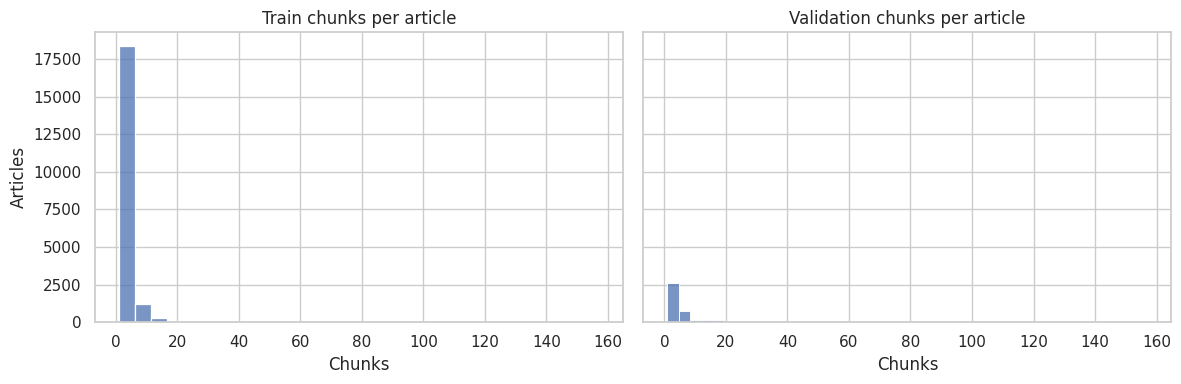

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharex=True, sharey=True)
sns.histplot(train_chunks.drop_duplicates("article_id")["num_chunks"], bins=30, ax=axes[0])
axes[0].set_title("Train chunks per article")
axes[0].set_xlabel("Chunks")
axes[0].set_ylabel("Articles")

sns.histplot(val_chunks.drop_duplicates("article_id")["num_chunks"], bins=30, ax=axes[1])
axes[1].set_title("Validation chunks per article")
axes[1].set_xlabel("Chunks")

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "sbert_chunks_per_article.png"), dpi=200, bbox_inches="tight")
plt.show()

## 7. Sentence-BERT Embeddings

In [12]:
sbert = SentenceTransformer(SBERT_MODEL_NAME)
print("Loaded", SBERT_MODEL_NAME)

modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/571 [00:00<?, ?B/s]

...

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/239 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Loaded all-mpnet-base-v2


In [13]:
def encode_chunks(chunk_df, split_name):
    texts = chunk_df["text"].fillna("").astype(str).tolist()
    embeddings = sbert.encode(
        texts,
        batch_size=ENCODE_BATCH_SIZE,
        show_progress_bar=True,
        convert_to_numpy=True,
        normalize_embeddings=True,
    )
    print(f"{split_name} chunk embeddings:", embeddings.shape)
    return embeddings

train_chunk_emb = encode_chunks(train_chunks, "train")
val_chunk_emb = encode_chunks(val_chunks, "validation")

Batches:   0%|          | 0/1067 [00:00<?, ?it/s]

train chunk embeddings: (68262, 768)


Batches:   0%|          | 0/350 [00:00<?, ?it/s]

validation chunk embeddings: (22369, 768)


## 8. Aggregate Sentence-BERT Chunks to Article Embeddings

In [14]:
def aggregate_to_articles(chunk_df, chunk_embeddings, original_df):
    emb_df = pd.DataFrame(chunk_embeddings)
    emb_df["article_id"] = chunk_df["article_id"].values

    article_emb = emb_df.groupby("article_id").mean().sort_index()
    article_labels = original_df.set_index("article_id").loc[article_emb.index, "label_3"].astype(int).values

    return article_emb.values, article_labels, article_emb.index.values

X_train_sbert, y_train_sbert, train_article_ids = aggregate_to_articles(train_chunks, train_chunk_emb, train_processed)
X_val_sbert, y_val_sbert, val_article_ids = aggregate_to_articles(val_chunks, val_chunk_emb, val_processed)

print("Train article embeddings:", X_train_sbert.shape)
print("Validation article embeddings:", X_val_sbert.shape)

np.save(os.path.join(OUTPUT_DIR, "X_train_sbert.npy"), X_train_sbert)
np.save(os.path.join(OUTPUT_DIR, "X_val_sbert.npy"), X_val_sbert)
np.save(os.path.join(OUTPUT_DIR, "y_train_3.npy"), y_train_sbert)
np.save(os.path.join(OUTPUT_DIR, "y_val_3.npy"), y_val_sbert)

Train article embeddings: (20000, 768)
Validation article embeddings: (4000, 768)


## 9. Sentence-BERT Classifiers

In [15]:
sbert_models = {
    "sbert_logistic_regression": Pipeline([
        ("scaler", StandardScaler()),
        ("clf", LogisticRegression(max_iter=2000, class_weight="balanced", random_state=SEED)),
    ]),
    "sbert_linear_svm": Pipeline([
        ("scaler", StandardScaler()),
        ("clf", LinearSVC(class_weight="balanced", random_state=SEED)),
    ]),
}

for name, model in sbert_models.items():
    print(f"\nTraining {name}...")
    model.fit(X_train_sbert, y_train_sbert)
    preds = model.predict(X_val_sbert)

    acc = accuracy_score(y_val_sbert, preds)
    macro = f1_score(y_val_sbert, preds, average="macro")
    all_results.append({"model": name, "family": "sentence_bert", "text_col": TEXT_COL, "accuracy": acc, "macro_f1": macro})
    trained_models[name] = model
    predictions[name] = preds

    print(f"Accuracy: {acc:.4f}")
    print(f"Macro F1: {macro:.4f}")
    print(classification_report(y_val_sbert, preds, target_names=LABEL_NAMES, zero_division=0))

results_df = pd.DataFrame(all_results).sort_values("macro_f1", ascending=False)
results_df


Training sbert_logistic_regression...
Accuracy: 0.4283
Macro F1: 0.3954
              precision    recall  f1-score   support

        left       0.42      0.64      0.51      1600
      center       0.35      0.28      0.31       800
       right       0.50      0.29      0.36      1600

    accuracy                           0.43      4000
   macro avg       0.42      0.40      0.40      4000
weighted avg       0.44      0.43      0.41      4000


Training sbert_linear_svm...
Accuracy: 0.4340
Macro F1: 0.3886
              precision    recall  f1-score   support

        left       0.42      0.69      0.52      1600
      center       0.41      0.22      0.28       800
       right       0.50      0.28      0.36      1600

    accuracy                           0.43      4000
   macro avg       0.44      0.40      0.39      4000
weighted avg       0.45      0.43      0.41      4000



,model,family,text_col,accuracy,macro_f1
4,sbert_logistic_regression,sentence_bert,clean_text,0.42825,0.395426
5,sbert_linear_svm,sentence_bert,clean_text,0.43400,0.388558
2,tfidf_linear_svm,classical,clean_text,0.44900,0.344899
1,tfidf_logistic_regression,classical,clean_text,0.42250,0.328105
3,bow_multinomial_nb,classical,clean_text,0.40525,0.308814
0,majority_class,classical,clean_text,0.40000,0.190476


## 10. Final Comparison and Confusion Matrix

In [16]:
results_path = os.path.join(OUTPUT_DIR, "three_class_all_baselines_results.csv")
results_df.to_csv(results_path, index=False)
print(results_path)
results_df

/content/three_class_all_baselines_outputs/three_class_all_baselines_results.csv


,model,family,text_col,accuracy,macro_f1
4,sbert_logistic_regression,sentence_bert,clean_text,0.42825,0.395426
5,sbert_linear_svm,sentence_bert,clean_text,0.43400,0.388558
2,tfidf_linear_svm,classical,clean_text,0.44900,0.344899
1,tfidf_logistic_regression,classical,clean_text,0.42250,0.328105
3,bow_multinomial_nb,classical,clean_text,0.40525,0.308814
0,majority_class,classical,clean_text,0.40000,0.190476


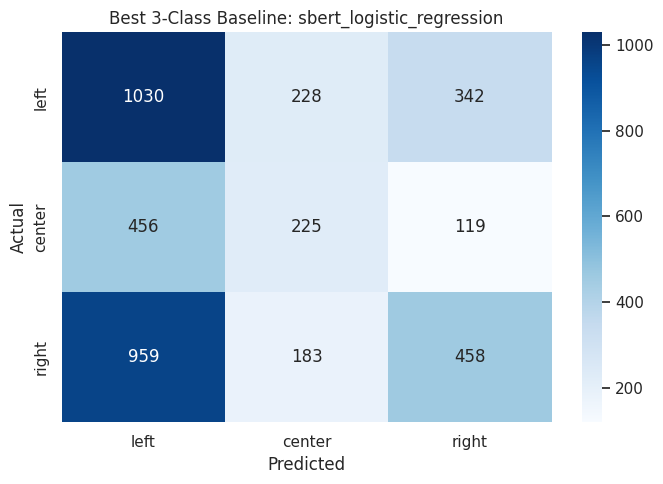

In [17]:
best_model_name = results_df.iloc[0]["model"]
best_preds = predictions[best_model_name]

# All predictions are aligned with val_processed article order.
cm = confusion_matrix(y_val, best_preds, labels=list(range(len(LABEL_NAMES))))
plt.figure(figsize=(7, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=LABEL_NAMES, yticklabels=LABEL_NAMES)
plt.title(f"Best 3-Class Baseline: {best_model_name}")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "best_model_confusion_matrix.png"), dpi=200, bbox_inches="tight")
plt.show()

## 11. Save Best Predictions and Models

In [18]:
for name, model in trained_models.items():
    joblib.dump(model, os.path.join(OUTPUT_DIR, f"{name}.joblib"))

preds_df = val_processed[["article_id", "title", "raw_text", "clean_text", "label", "label_name", "label_3", "label_3_name"]].copy()
for name, preds in predictions.items():
    preds_df[f"pred_{name}"] = preds
    preds_df[f"pred_label_{name}"] = [ID_TO_LABEL[p] for p in preds]

preds_path = os.path.join(OUTPUT_DIR, "all_baseline_predictions.csv")
preds_df.to_csv(preds_path, index=False)
print(preds_path)

/content/three_class_all_baselines_outputs/all_baseline_predictions.csv
